In [1]:
#Ride-Sharing Demand & Revenue Intelligence
#Business Objective
#The goal of this project is to analyze NYC taxi ride data to understand demand patterns, revenue distribution, and prepare the dataset for dynamic surge pricing simulation.

#This notebook focuses on:

#Data cleaning
#Outlier removal
#Feature engineering
#Preparing a clean dataset for analysis

In [2]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns',None)

In [3]:
df=pd.read_parquet(r"C:\Users\baavi\Downloads\yellow_tripdata_2026-01.parquet")
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,2,2026-01-01 00:54:04,2026-01-01 00:59:37,1.0,0.97,1.0,N,239,238,1,7.2,1.00,0.5,3.66,0.0,1.0,15.86,2.5,0.0,0.00
1,1,2026-01-01 00:34:04,2026-01-01 00:39:47,0.0,0.90,1.0,N,163,162,2,7.9,4.25,0.5,0.00,0.0,1.0,13.65,2.5,0.0,0.75
2,1,2026-01-01 00:57:06,2026-01-01 01:05:59,0.0,1.40,1.0,N,43,237,1,10.7,4.25,0.5,2.50,0.0,1.0,18.95,2.5,0.0,0.75
3,2,2026-01-01 00:15:22,2026-01-01 00:58:10,4.0,5.58,1.0,N,142,209,1,38.7,1.00,0.5,11.11,0.0,1.0,55.56,2.5,0.0,0.75
4,2,2026-01-01 00:27:13,2026-01-01 00:40:43,0.0,2.16,1.0,N,88,144,1,13.5,1.00,0.5,3.85,0.0,1.0,23.10,2.5,0.0,0.75


In [4]:
df.tail()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
3724884,2,2026-01-31 23:26:00,2026-01-31 23:39:16,NaN,1.62,NaN,None,237,161,0,17.09,0.0,0.5,0.0,0.0,1.0,21.84,NaN,NaN,0.75
3724885,2,2026-01-31 23:33:53,2026-01-31 23:34:07,NaN,0.00,NaN,None,42,42,0,23.19,0.0,0.5,0.0,0.0,1.0,24.69,NaN,NaN,0.00
3724886,2,2026-01-31 23:40:23,2026-01-31 23:56:10,NaN,6.84,NaN,None,137,69,0,29.21,0.0,0.5,0.0,0.0,1.0,33.96,NaN,NaN,0.75
3724887,2,2026-01-31 23:10:21,2026-01-31 23:20:00,NaN,1.53,NaN,None,137,162,0,19.19,0.0,0.5,0.0,0.0,1.0,23.94,NaN,NaN,0.75
3724888,2,2026-01-31 23:43:12,2026-01-31 23:57:45,NaN,1.04,NaN,None,148,148,0,16.49,0.0,0.5,0.0,0.0,1.0,21.24,NaN,NaN,0.75


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3724889 entries, 0 to 3724888
Data columns (total 20 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int32         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int32         
 8   DOLocationID           int32         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  Airport_fee           

In [6]:
df.isnull().sum()

VendorID                       0
tpep_pickup_datetime           0
tpep_dropoff_datetime          0
passenger_count          1088058
trip_distance                  0
RatecodeID               1088058
store_and_fwd_flag       1088058
PULocationID                   0
DOLocationID                   0
payment_type                   0
fare_amount                    0
extra                          0
mta_tax                        0
tip_amount                     0
tolls_amount                   0
improvement_surcharge          0
total_amount                   0
congestion_surcharge     1088058
Airport_fee              1088058
cbd_congestion_fee             0
dtype: int64

In [7]:
df.shape

(3724889, 20)

In [8]:
print("Percentage of missing values : ")
print(round((df.isnull().sum() / len(df)) * 100, 2))

Percentage of missing values : 
VendorID                  0.00
tpep_pickup_datetime      0.00
tpep_dropoff_datetime     0.00
passenger_count          29.21
trip_distance             0.00
RatecodeID               29.21
store_and_fwd_flag       29.21
PULocationID              0.00
DOLocationID              0.00
payment_type              0.00
fare_amount               0.00
extra                     0.00
mta_tax                   0.00
tip_amount                0.00
tolls_amount              0.00
improvement_surcharge     0.00
total_amount              0.00
congestion_surcharge     29.21
Airport_fee              29.21
cbd_congestion_fee        0.00
dtype: float64


In [9]:
print("columns that have null values:")
df.columns[df.isnull().any()].tolist()

columns that have null values:


['passenger_count',
 'RatecodeID',
 'store_and_fwd_flag',
 'congestion_surcharge',
 'Airport_fee']

In [10]:
df.isnull().sum()

VendorID                       0
tpep_pickup_datetime           0
tpep_dropoff_datetime          0
passenger_count          1088058
trip_distance                  0
RatecodeID               1088058
store_and_fwd_flag       1088058
PULocationID                   0
DOLocationID                   0
payment_type                   0
fare_amount                    0
extra                          0
mta_tax                        0
tip_amount                     0
tolls_amount                   0
improvement_surcharge          0
total_amount                   0
congestion_surcharge     1088058
Airport_fee              1088058
cbd_congestion_fee             0
dtype: int64

In [11]:
df.columns

Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag',
       'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra',
       'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
       'total_amount', 'congestion_surcharge', 'Airport_fee',
       'cbd_congestion_fee'],
      dtype='object')

In [12]:
df.drop(columns=['RatecodeID','store_and_fwd_flag','congestion_surcharge','Airport_fee'],inplace=True)

In [13]:
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,cbd_congestion_fee
0,2,2026-01-01 00:54:04,2026-01-01 00:59:37,1.0,0.97,239,238,1,7.2,1.00,0.5,3.66,0.0,1.0,15.86,0.00
1,1,2026-01-01 00:34:04,2026-01-01 00:39:47,0.0,0.90,163,162,2,7.9,4.25,0.5,0.00,0.0,1.0,13.65,0.75
2,1,2026-01-01 00:57:06,2026-01-01 01:05:59,0.0,1.40,43,237,1,10.7,4.25,0.5,2.50,0.0,1.0,18.95,0.75
3,2,2026-01-01 00:15:22,2026-01-01 00:58:10,4.0,5.58,142,209,1,38.7,1.00,0.5,11.11,0.0,1.0,55.56,0.75
4,2,2026-01-01 00:27:13,2026-01-01 00:40:43,0.0,2.16,88,144,1,13.5,1.00,0.5,3.85,0.0,1.0,23.10,0.75


In [14]:
columns_to_keep = ['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'PULocationID', 'DOLocationID',
       'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount',
       'tolls_amount', 'improvement_surcharge', 'total_amount',
       'cbd_congestion_fee']
print(columns_to_keep)

['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'cbd_congestion_fee']


In [15]:
df_1=pd.read_parquet(r"C:\Users\baavi\Downloads\yellow_tripdata_2026-01.parquet",columns=columns_to_keep)
df_1.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,cbd_congestion_fee
0,2,2026-01-01 00:54:04,2026-01-01 00:59:37,1.0,0.97,239,238,1,7.2,1.00,0.5,3.66,0.0,1.0,15.86,0.00
1,1,2026-01-01 00:34:04,2026-01-01 00:39:47,0.0,0.90,163,162,2,7.9,4.25,0.5,0.00,0.0,1.0,13.65,0.75
2,1,2026-01-01 00:57:06,2026-01-01 01:05:59,0.0,1.40,43,237,1,10.7,4.25,0.5,2.50,0.0,1.0,18.95,0.75
3,2,2026-01-01 00:15:22,2026-01-01 00:58:10,4.0,5.58,142,209,1,38.7,1.00,0.5,11.11,0.0,1.0,55.56,0.75
4,2,2026-01-01 00:27:13,2026-01-01 00:40:43,0.0,2.16,88,144,1,13.5,1.00,0.5,3.85,0.0,1.0,23.10,0.75


In [16]:
df_1=df_1.sample(1_500_000,random_state=42)

In [17]:
df_1.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,cbd_congestion_fee
1511419,1,2026-01-18 12:35:13,2026-01-18 12:46:05,1.0,3.90,68,238,1,17.00,3.25,0.5,2.50,0.00,1.0,24.25,0.75
3524883,2,2026-01-28 01:01:57,2026-01-28 01:34:45,NaN,13.95,69,61,0,49.13,0.00,0.5,0.00,7.46,1.0,58.09,0.00
652868,2,2026-01-09 10:35:27,2026-01-09 11:05:50,1.0,13.79,13,138,1,55.50,5.00,0.5,19.57,0.00,1.0,84.82,0.75
2115729,2,2026-01-24 22:26:51,2026-01-24 22:37:03,1.0,1.76,164,79,2,11.40,1.00,0.5,0.00,0.00,1.0,17.15,0.75
2645236,2,2026-01-01 01:59:23,2026-01-01 02:13:41,NaN,7.42,74,232,0,41.06,0.00,0.5,0.00,0.00,1.0,45.81,0.75


In [18]:
len(df_1)

1500000

In [19]:
df_1.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,cbd_congestion_fee
1511419,1,2026-01-18 12:35:13,2026-01-18 12:46:05,1.0,3.90,68,238,1,17.00,3.25,0.5,2.50,0.00,1.0,24.25,0.75
3524883,2,2026-01-28 01:01:57,2026-01-28 01:34:45,NaN,13.95,69,61,0,49.13,0.00,0.5,0.00,7.46,1.0,58.09,0.00
652868,2,2026-01-09 10:35:27,2026-01-09 11:05:50,1.0,13.79,13,138,1,55.50,5.00,0.5,19.57,0.00,1.0,84.82,0.75
2115729,2,2026-01-24 22:26:51,2026-01-24 22:37:03,1.0,1.76,164,79,2,11.40,1.00,0.5,0.00,0.00,1.0,17.15,0.75
2645236,2,2026-01-01 01:59:23,2026-01-01 02:13:41,NaN,7.42,74,232,0,41.06,0.00,0.5,0.00,0.00,1.0,45.81,0.75


In [20]:
df_1.columns

Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'PULocationID', 'DOLocationID',
       'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount',
       'tolls_amount', 'improvement_surcharge', 'total_amount',
       'cbd_congestion_fee'],
      dtype='object')

In [21]:
df_1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1500000 entries, 1511419 to 3292841
Data columns (total 16 columns):
 #   Column                 Non-Null Count    Dtype         
---  ------                 --------------    -----         
 0   VendorID               1500000 non-null  int32         
 1   tpep_pickup_datetime   1500000 non-null  datetime64[us]
 2   tpep_dropoff_datetime  1500000 non-null  datetime64[us]
 3   passenger_count        1061240 non-null  float64       
 4   trip_distance          1500000 non-null  float64       
 5   PULocationID           1500000 non-null  int32         
 6   DOLocationID           1500000 non-null  int32         
 7   payment_type           1500000 non-null  int64         
 8   fare_amount            1500000 non-null  float64       
 9   extra                  1500000 non-null  float64       
 10  mta_tax                1500000 non-null  float64       
 11  tip_amount             1500000 non-null  float64       
 12  tolls_amount           1500

In [22]:
df_1.isnull().sum()

VendorID                      0
tpep_pickup_datetime          0
tpep_dropoff_datetime         0
passenger_count          438760
trip_distance                 0
PULocationID                  0
DOLocationID                  0
payment_type                  0
fare_amount                   0
extra                         0
mta_tax                       0
tip_amount                    0
tolls_amount                  0
improvement_surcharge         0
total_amount                  0
cbd_congestion_fee            0
dtype: int64

<Axes: ylabel='passenger_count'>

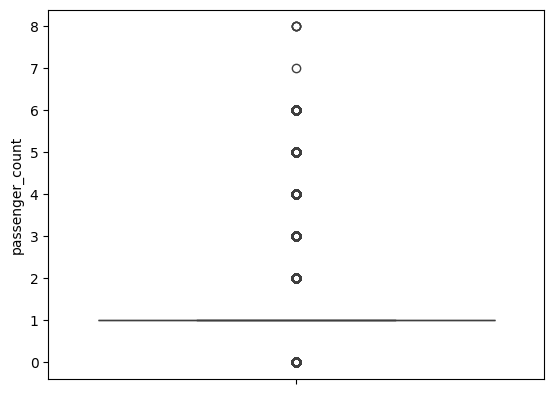

In [23]:
import seaborn as sns
sns.boxplot(df_1['passenger_count'])

In [24]:
median_passenger=df_1['passenger_count'].median()

In [25]:
df_1['passenger_count']=df_1['passenger_count'].fillna(median_passenger)

In [26]:
df_1.isnull().sum()

VendorID                 0
tpep_pickup_datetime     0
tpep_dropoff_datetime    0
passenger_count          0
trip_distance            0
PULocationID             0
DOLocationID             0
payment_type             0
fare_amount              0
extra                    0
mta_tax                  0
tip_amount               0
tolls_amount             0
improvement_surcharge    0
total_amount             0
cbd_congestion_fee       0
dtype: int64

In [27]:
#checking for invalid records
df_1=df_1[df_1['trip_distance']>0]
df_1 = df_1[df_1["fare_amount"] > 0]
df_1 = df_1[df_1["total_amount"] > 0]
df_1 = df_1[df_1["passenger_count"] > 0]

In [28]:
print("shape after removing invalid records:", df_1.shape)

shape after removing invalid records: (1428176, 16)


In [29]:
#creating new column "trip_duration-min"
df_1["trip_duration_min"] = round(((df_1["tpep_dropoff_datetime"] - df_1["tpep_pickup_datetime"]).dt.total_seconds() / 60), 2)

In [30]:
df_1['trip_duration_min']

1511419    10.87
3524883    32.80
652868     30.38
2115729    10.20
2645236    14.30
           ...  
2785742    19.43
911385      0.00
3219791    20.98
841094      5.62
3292841    12.68
Name: trip_duration_min, Length: 1428176, dtype: float64

In [31]:
df_1 = df_1[df_1["trip_duration_min"] > 1]

In [32]:
df_1["pickup_hour"] = df_1["tpep_pickup_datetime"].dt.hour
df_1["pickup_day"] = df_1["tpep_pickup_datetime"].dt.day
df_1["pickup_weekday"] = df_1["tpep_pickup_datetime"].dt.weekday

In [33]:
df_1.columns

Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'PULocationID', 'DOLocationID',
       'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount',
       'tolls_amount', 'improvement_surcharge', 'total_amount',
       'cbd_congestion_fee', 'trip_duration_min', 'pickup_hour', 'pickup_day',
       'pickup_weekday'],
      dtype='object')

In [34]:
df_1["is_weekend"] = df_1["pickup_weekday"].isin([5,6]).astype(int)

In [35]:
fare_low=df_1['fare_amount'].quantile(0.01)
fare_high=df_1['fare_amount'].quantile(0.99)
dist_low=df_1['trip_distance'].quantile(0.01)
dist_high=df_1['trip_distance'].quantile(0.99)


In [36]:
df_1 = df_1[(df_1["fare_amount"] >= fare_low) & (df_1["fare_amount"] <= fare_high)]
df_1 = df_1[(df_1["trip_distance"] >= dist_low) & (df_1["trip_distance"] <= dist_high)]

In [37]:
print("shape after removal of outlier:",df_1.shape)

shape after removal of outlier: (1367288, 21)


In [38]:
df_1["revenue_per_mile"] = round(df_1["total_amount"] / df_1["trip_distance"], 2)
df_1["revenue_per_minute"] = round(df_1["total_amount"] / df_1["trip_duration_min"], 2)
df_1["tip_percentage"] = round(df_1["tip_amount"] / df_1["fare_amount"], 2)

In [39]:
df_1.describe()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,cbd_congestion_fee,trip_duration_min,pickup_hour,pickup_day,pickup_weekday,is_weekend,revenue_per_mile,revenue_per_minute,tip_percentage
count,1.367288e+06,1367288,1367288,1.367288e+06,1.367288e+06,1.367288e+06,1.367288e+06,1.367288e+06,1.367288e+06,1.367288e+06,1.367288e+06,1.367288e+06,1.367288e+06,1.367288e+06,1.367288e+06,1.367288e+06,1.367288e+06,1.367288e+06,1.367288e+06,1.367288e+06,1.367288e+06,1.367288e+06,1.367288e+06,1.367288e+06
mean,1.802350e+00,2026-01-17 00:39:25.016187,2026-01-17 00:56:27.211456,1.184786e+00,3.279718e+00,1.617664e+02,1.612835e+02,8.253470e-01,2.001265e+01,1.088579e+00,4.977989e-01,2.571218e+00,4.331344e-01,9.688570e-01,2.840980e+01,5.369006e-01,1.703659e+01,1.402371e+01,1.642218e+01,3.166464e+00,2.902951e-01,1.355417e+01,2.023463e+00,1.621908e-01
min,1.000000e+00,2026-01-01 00:00:09,2026-01-01 00:04:15,1.000000e+00,2.200000e-01,1.000000e+00,1.000000e+00,0.000000e+00,4.400000e+00,-7.500000e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,5.710000e+00,0.000000e+00,1.020000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,4.600000e-01,0.000000e+00,0.000000e+00
25%,2.000000e+00,2026-01-09 17:41:10.500000,2026-01-09 17:58:38,1.000000e+00,1.100000e+00,1.140000e+02,1.070000e+02,0.000000e+00,1.000000e+01,0.000000e+00,5.000000e-01,0.000000e+00,0.000000e+00,1.000000e+00,1.722000e+01,0.000000e+00,8.370000e+00,1.000000e+01,9.000000e+00,2.000000e+00,0.000000e+00,8.150000e+00,1.490000e+00,0.000000e+00
50%,2.000000e+00,2026-01-16 20:50:06.500000,2026-01-16 21:05:14.500000,1.000000e+00,1.900000e+00,1.610000e+02,1.620000e+02,1.000000e+00,1.550000e+01,0.000000e+00,5.000000e-01,2.000000e+00,0.000000e+00,1.000000e+00,2.295000e+01,7.500000e-01,1.343000e+01,1.500000e+01,1.600000e+01,3.000000e+00,0.000000e+00,1.184000e+01,1.830000e+00,1.700000e-01
75%,2.000000e+00,2026-01-24 02:36:38.500000,2026-01-24 02:50:13.250000,1.000000e+00,3.780000e+00,2.330000e+02,2.340000e+02,1.000000e+00,2.523000e+01,2.500000e+00,5.000000e-01,3.750000e+00,0.000000e+00,1.000000e+00,3.295000e+01,7.500000e-01,2.093000e+01,1.900000e+01,2.400000e+01,5.000000e+00,1.000000e+00,1.659000e+01,2.320000e+00,2.900000e-01
max,6.000000e+00,2026-01-31 23:59:59,2026-02-01 23:35:31,7.000000e+00,1.963000e+01,2.650000e+02,2.650000e+02,4.000000e+00,7.720000e+01,1.325000e+01,4.750000e+00,7.660000e+02,1.024600e+02,1.000000e+00,7.992000e+02,7.500000e-01,5.293330e+03,2.300000e+01,3.100000e+01,6.000000e+00,1.000000e+00,5.328000e+02,9.701000e+01,2.416000e+01
std,3.999498e-01,NaN,NaN,5.702710e-01,3.625016e+00,6.716744e+01,7.067977e+01,6.373082e-01,1.431029e+01,1.712258e+00,3.380901e-02,3.457203e+00,1.792853e+00,1.736623e-01,1.745609e+01,3.382503e-01,2.408083e+01,6.051287e+00,8.848094e+00,1.835150e+00,4.538987e-01,8.681611e+00,1.005480e+00,1.665731e-01


In [40]:
len(df_1.columns)

24

In [41]:
df_1.shape

(1367288, 24)

In [42]:
df_1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1367288 entries, 1511419 to 3292841
Data columns (total 24 columns):
 #   Column                 Non-Null Count    Dtype         
---  ------                 --------------    -----         
 0   VendorID               1367288 non-null  int32         
 1   tpep_pickup_datetime   1367288 non-null  datetime64[us]
 2   tpep_dropoff_datetime  1367288 non-null  datetime64[us]
 3   passenger_count        1367288 non-null  float64       
 4   trip_distance          1367288 non-null  float64       
 5   PULocationID           1367288 non-null  int32         
 6   DOLocationID           1367288 non-null  int32         
 7   payment_type           1367288 non-null  int64         
 8   fare_amount            1367288 non-null  float64       
 9   extra                  1367288 non-null  float64       
 10  mta_tax                1367288 non-null  float64       
 11  tip_amount             1367288 non-null  float64       
 12  tolls_amount           1367

In [43]:
df_1.to_csv("Cleaned_yellow_tripdata_2025-01.csv", index=False)

In [44]:
df_1.to_parquet("Cleaned_yellow_tripdata_2025-01.parquet", index=False)

In [45]:
df_1.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,cbd_congestion_fee,trip_duration_min,pickup_hour,pickup_day,pickup_weekday,is_weekend,revenue_per_mile,revenue_per_minute,tip_percentage
1511419,1,2026-01-18 12:35:13,2026-01-18 12:46:05,1.0,3.90,68,238,1,17.00,3.25,0.5,2.50,0.00,1.0,24.25,0.75,10.87,12,18,6,1,6.22,2.23,0.15
3524883,2,2026-01-28 01:01:57,2026-01-28 01:34:45,1.0,13.95,69,61,0,49.13,0.00,0.5,0.00,7.46,1.0,58.09,0.00,32.80,1,28,2,0,4.16,1.77,0.00
652868,2,2026-01-09 10:35:27,2026-01-09 11:05:50,1.0,13.79,13,138,1,55.50,5.00,0.5,19.57,0.00,1.0,84.82,0.75,30.38,10,9,4,0,6.15,2.79,0.35
2115729,2,2026-01-24 22:26:51,2026-01-24 22:37:03,1.0,1.76,164,79,2,11.40,1.00,0.5,0.00,0.00,1.0,17.15,0.75,10.20,22,24,5,1,9.74,1.68,0.00
2645236,2,2026-01-01 01:59:23,2026-01-01 02:13:41,1.0,7.42,74,232,0,41.06,0.00,0.5,0.00,0.00,1.0,45.81,0.75,14.30,1,1,3,0,6.17,3.20,0.00


In [46]:
len(df_1)

1367288

In [47]:
df_1=pd.read_parquet("Cleaned_yellow_tripdata_2025-01.parquet")

In [48]:
df_1.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,cbd_congestion_fee,trip_duration_min,pickup_hour,pickup_day,pickup_weekday,is_weekend,revenue_per_mile,revenue_per_minute,tip_percentage
0,1,2026-01-18 12:35:13,2026-01-18 12:46:05,1.0,3.90,68,238,1,17.00,3.25,0.5,2.50,0.00,1.0,24.25,0.75,10.87,12,18,6,1,6.22,2.23,0.15
1,2,2026-01-28 01:01:57,2026-01-28 01:34:45,1.0,13.95,69,61,0,49.13,0.00,0.5,0.00,7.46,1.0,58.09,0.00,32.80,1,28,2,0,4.16,1.77,0.00
2,2,2026-01-09 10:35:27,2026-01-09 11:05:50,1.0,13.79,13,138,1,55.50,5.00,0.5,19.57,0.00,1.0,84.82,0.75,30.38,10,9,4,0,6.15,2.79,0.35
3,2,2026-01-24 22:26:51,2026-01-24 22:37:03,1.0,1.76,164,79,2,11.40,1.00,0.5,0.00,0.00,1.0,17.15,0.75,10.20,22,24,5,1,9.74,1.68,0.00
4,2,2026-01-01 01:59:23,2026-01-01 02:13:41,1.0,7.42,74,232,0,41.06,0.00,0.5,0.00,0.00,1.0,45.81,0.75,14.30,1,1,3,0,6.17,3.20,0.00
